In [1]:
# ===============================================
# 🧩 Colab_SyncMate — universal Colab↔GitHub helper
# ===============================================

from google.colab import userdata
from pathlib import Path
import os, subprocess, datetime

# --- CONFIG ---
GITHUB_USERNAME = "Retro099"                    # change if needed
GITHUB_REPO = "ML-Projects"                     # your repo name
PROJECT_FOLDER = "Credit_Card_Fraud_Detection/notebooks"  # default project folder

# --- TOKEN SETUP ---
ACCESS_TOKEN = userdata.get('GITHUB_TOKEN')
if not ACCESS_TOKEN:
    raise ValueError("⚠️ Missing GitHub token. Add one via Runtime → Run time secrets → name it GITHUB_TOKEN")

# --- PATHS ---
BASE_PATH = Path("/content")
REPO_PATH = BASE_PATH / GITHUB_REPO
REPO_URL = f"https://{ACCESS_TOKEN}@github.com/{GITHUB_USERNAME}/{GITHUB_REPO}.git"

# --- CLONE OR UPDATE REPO ---
if REPO_PATH.exists():
    os.chdir(REPO_PATH)
    subprocess.run(["git", "pull"], check=False)
else:
    os.chdir(BASE_PATH)
    subprocess.run(["git", "clone", REPO_URL], check=False)
    os.chdir(REPO_PATH)

# --- MOVE TO PROJECT FOLDER ---
proj_path = REPO_PATH / PROJECT_FOLDER
proj_path.mkdir(parents=True, exist_ok=True)
os.chdir(proj_path)

print(f"✅ Repo ready at: {REPO_PATH}")
print(f"✅ Project folder: {proj_path}")

# --- UTILITIES ---
def save_notebook(dst=None):
    """Force-save current notebook state to disk."""
    from google.colab import _message
    if not dst:
        dst = os.getcwd()
    _message.blocking_request('save_notebook', {'path': dst})
    print(f"💾 Notebook saved to {dst}")

def quick_commit_push(msg="Autosave commit"):
    """Commit and push changes quickly to GitHub."""
    os.chdir(REPO_PATH)
    subprocess.run(["git", "add", "-A"], check=False)
    subprocess.run(["git", "commit", "-m", msg], check=False)
    subprocess.run(["git", "push", "origin", "main"], check=False)
    print("✅ Repo synced with GitHub")

def safe_backup(tag=None):
    """Create a timestamped local backup inside /content."""
    tag = tag or datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    backup_dir = BASE_PATH / f"Backup_{GITHUB_REPO}_{tag}"
    subprocess.run(["cp", "-r", str(REPO_PATH), str(backup_dir)])
    print(f"🧾 Local backup created at: {backup_dir}")

def unified_shutdown():
    """Cleanly commit, push, and unmount before ending session."""
    try:
        quick_commit_push("Session wrap-up via Colab_SyncMate")
    except Exception as e:
        print("⚠️ Commit/push skipped:", e)
    try:
        from google.colab import drive
        drive.flush_and_unmount()
    except:
        pass
    print("💤 Session safely closed. Now disconnect runtime via Runtime → Disconnect and delete runtime.")

print("\n🧩 Colab_SyncMate initialized.\nAvailable commands:")
print("  • save_notebook()        – flush in-memory notebook")
print("  • quick_commit_push(msg) – commit and push instantly")
print("  • safe_backup(tag)       – create timestamped backup")
print("  • unified_shutdown()     – final sync + clean close")
print("\n⚙️  Tip: Run this notebook once per Colab session before opening your project.")


✅ Repo ready at: /content/ML-Projects
✅ Project folder: /content/ML-Projects/Credit_Card_Fraud_Detection/notebooks

🧩 Colab_SyncMate initialized.
Available commands:
  • save_notebook()        – flush in-memory notebook
  • quick_commit_push(msg) – commit and push instantly
  • safe_backup(tag)       – create timestamped backup
  • unified_shutdown()     – final sync + clean close

⚙️  Tip: Run this notebook once per Colab session before opening your project.


In [2]:
from pathlib import Path
import os

root = Path("/content/ML-Projects/Credit_Card_Fraud_Detection")
root.mkdir(parents=True, exist_ok=True)

for sub in ["notebooks", "data_sample", "artifacts", "assets"]:
    (root / sub).mkdir(exist_ok=True)

print("Folder structure ready:")
!tree -L 2 /content/ML-Projects/Credit_Card_Fraud_Detection

Folder structure ready:
/bin/bash: line 1: tree: command not found


In [5]:
# ── 1. Imports for EDA ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

DATA_PATH = Path("/content/ML-Projects/Credit_Card_Fraud_Detection/data_sample/creditcard.csv")
df = pd.read_csv(DATA_PATH)
print("Dataset loaded:", df.shape)

Dataset loaded: (284807, 31)


In [6]:
# ── 2. Quick overview ────────────────────────────────────────────────────────
print("\nDescriptive statistics (all features):")
print(df.describe().T[["mean", "std", "min", "max"]].round(3))

print("\nTransaction Amount stats:")
print(df["Amount"].describe().round(2))

print("\nTime (seconds since first transaction):")
print(df["Time"].describe().round(2))


Descriptive statistics (all features):
             mean        std      min         max
Time    94813.860  47488.146    0.000  172792.000
V1          0.000      1.959  -56.408       2.455
V2          0.000      1.651  -72.716      22.058
V3         -0.000      1.516  -48.326       9.383
V4          0.000      1.416   -5.683      16.875
V5          0.000      1.380 -113.743      34.802
V6          0.000      1.332  -26.161      73.302
V7         -0.000      1.237  -43.557     120.589
V8          0.000      1.194  -73.217      20.007
V9         -0.000      1.099  -13.434      15.595
V10         0.000      1.089  -24.588      23.745
V11         0.000      1.021   -4.797      12.019
V12        -0.000      0.999  -18.684       7.848
V13         0.000      0.995   -5.792       7.127
V14         0.000      0.959  -19.214      10.527
V15         0.000      0.915   -4.499       8.878
V16         0.000      0.876  -14.130      17.315
V17        -0.000      0.849  -25.163       9.254
V18       

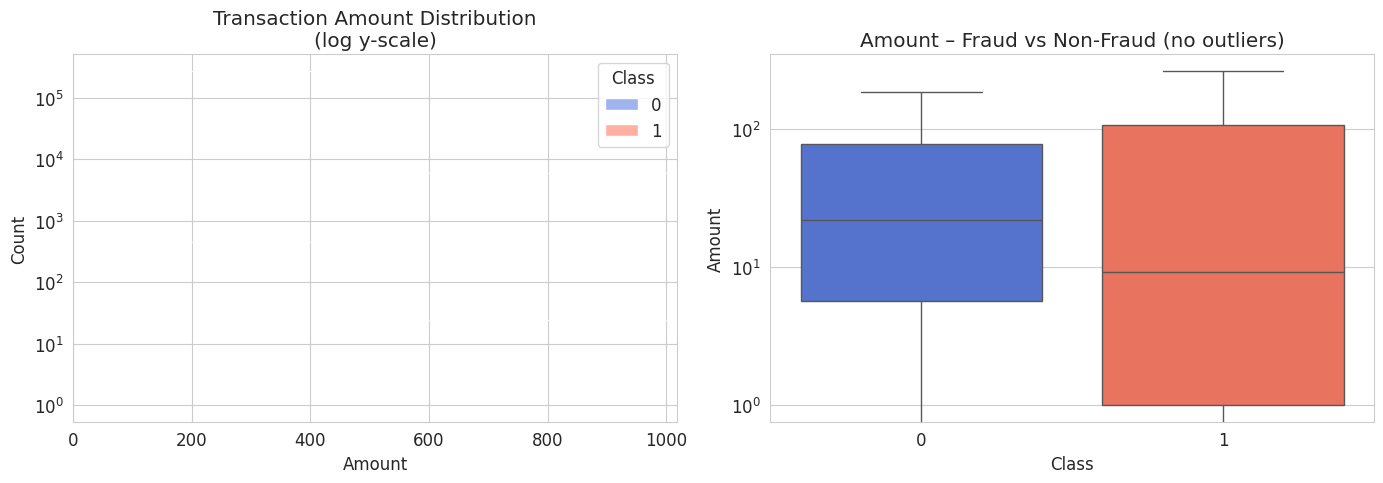

In [8]:
# ── 3. Class-conditional Amount distribution (fixed version) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram with hue
sns.histplot(data=df, x="Amount", hue="Class", bins=50, log_scale=(False, True),
             palette={0: "royalblue", 1: "tomato"}, ax=axes[0])
axes[0].set_title("Transaction Amount Distribution\n(log y-scale)")
axes[0].set_xlim(0, df["Amount"].quantile(0.99))

# Right: boxplot – now with hue="Class" so palette keys match Class values (0,1)
sns.boxplot(data=df, x="Class", y="Amount", hue="Class",        # ← added this
            palette={0: "royalblue", 1: "tomato"},
            showfliers=False, legend=False, ax=axes[1])         # ← legend=False to avoid duplicate legend
axes[1].set_title("Amount – Fraud vs Non-Fraud (no outliers)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("/content/ML-Projects/Credit_Card_Fraud_Detection/assets/amount_distribution_fixed.png",
            dpi=150, bbox_inches="tight")
plt.show()

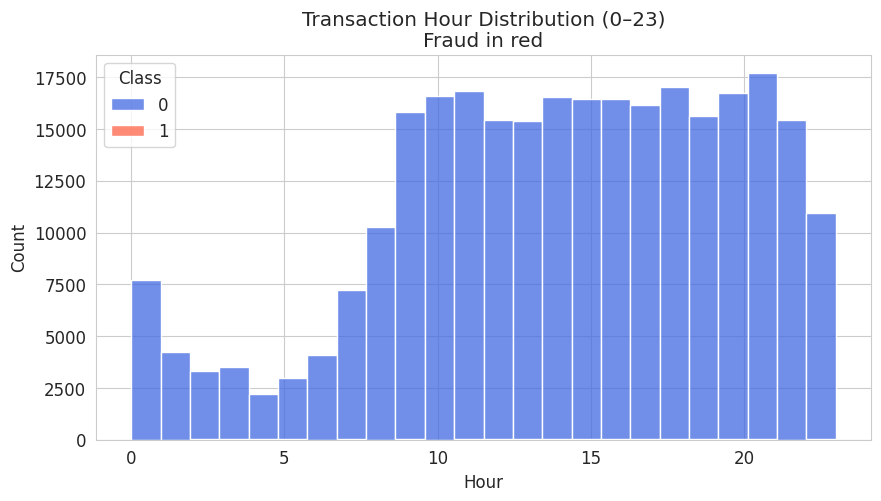

In [9]:
# ── 4. Time of day pattern (convert seconds → hours) ─────────────────────────
df["Hour"] = (df["Time"] // 3600) % 24

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="Hour", hue="Class", multiple="stack", bins=24,
             palette={0: "royalblue", 1: "tomato"}, ax=ax)
ax.set_title("Transaction Hour Distribution (0–23)\nFraud in red")
plt.savefig("/content/ML-Projects/Credit_Card_Fraud_Detection/assets/hour_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

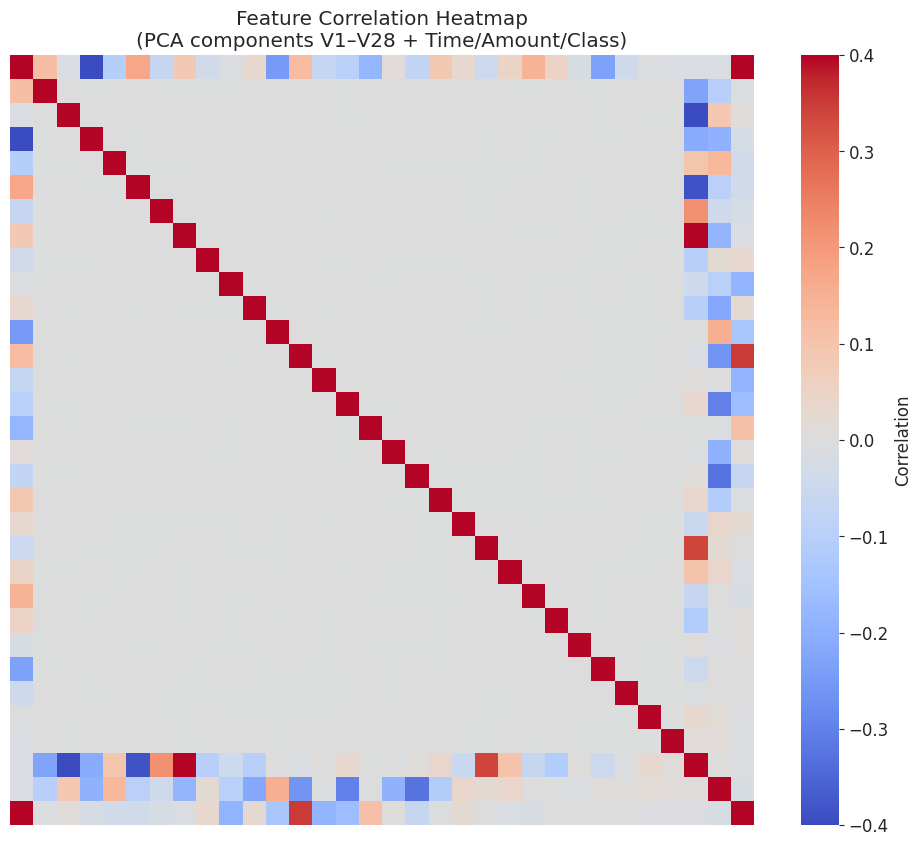


Top 10 features correlated with Class (absolute):
Class    1.0000
V17      0.3265
V14      0.3025
V12      0.2606
V10      0.2169
V16      0.1965
V3       0.1930
V7       0.1873
V11      0.1549
V4       0.1334
V18      0.1115
Name: Class, dtype: float64


In [10]:
# ── 5. Correlation heatmap (focus on Class) ──────────────────────────────────
corr = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-0.4, vmax=0.4,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Correlation'})
plt.title("Feature Correlation Heatmap\n(PCA components V1–V28 + Time/Amount/Class)")
plt.savefig("/content/ML-Projects/Credit_Card_Fraud_Detection/assets/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Top correlations with Class (absolute value)
print("\nTop 10 features correlated with Class (absolute):")
print(corr["Class"].abs().sort_values(ascending=False).head(11).round(4))

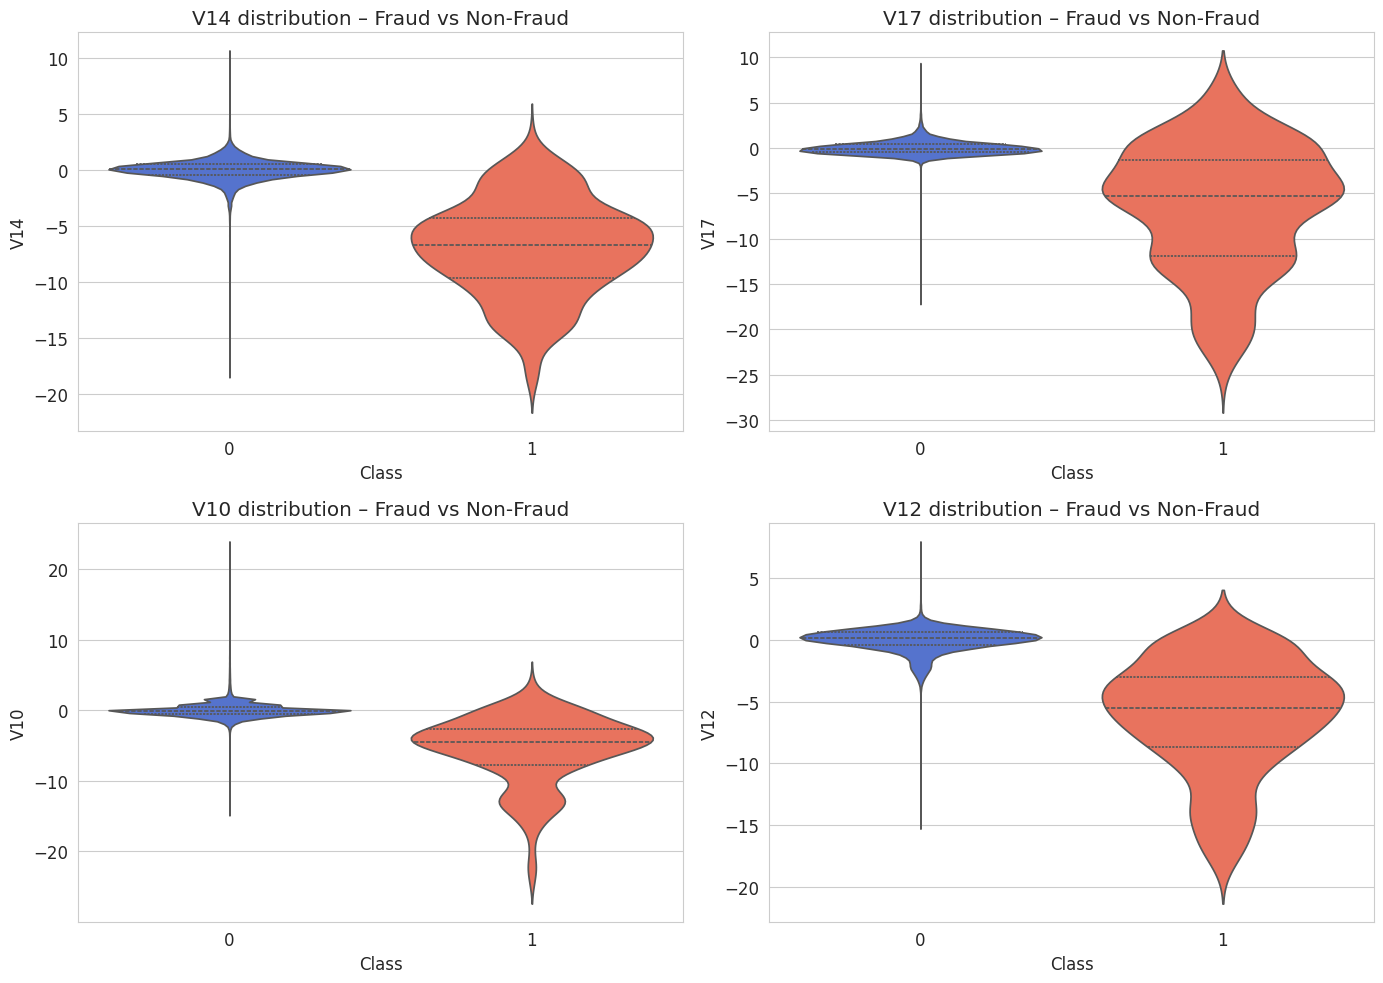

In [12]:
# ── 6. Violin plots for strong PCA features (fixed) ──────────────────────────
strong_features = ["V14", "V17", "V10", "V12"]   # highest fraud separation usually

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feat in enumerate(strong_features):
    sns.violinplot(
        data=df,
        x="Class",
        y=feat,
        hue="Class",                      # ← this line fixes it
        palette={0: "royalblue", 1: "tomato"},
        inner="quartile",
        legend=False,                     # ← removes duplicate legend
        ax=axes[i]
    )
    axes[i].set_title(f"{feat} distribution – Fraud vs Non-Fraud")

plt.tight_layout()
plt.savefig(
    "/content/ML-Projects/Credit_Card_Fraud_Detection/assets/pca_violins_fixed.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

In [13]:
# ── Day 3: Preprocessing & Imbalance Handling ────────────────────────────────
# Imports
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path("/content/ML-Projects/Credit_Card_Fraud_Detection/data_sample/creditcard.csv")
df = pd.read_csv(DATA_PATH)

X = df.drop("Class", axis=1)
y = df["Class"]

print("Full dataset shape:", X.shape, y.shape)

Full dataset shape: (284807, 30) (284807,)


In [14]:
# ── 1. Stratified split (very important!) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train class distribution:\n", y_train.value_counts(normalize=True) * 100)
print("Test class distribution:\n", y_test.value_counts(normalize=True) * 100)

Train class distribution:
 Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64
Test class distribution:
 Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [15]:
# ── 2. Preprocessing pipeline (scale only Time & Amount) ─────────────────────
num_features = ["Time", "Amount"]
pca_features = [f"V{i}" for i in range(1, 29)]  # V1–V28 already PCA-scaled

preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), num_features),
        # PCA features pass through unchanged
        ("passthrough", "passthrough", pca_features)
    ],
    remainder="drop"
)

In [16]:
# ── 3. Baseline: Dummy classifier (most frequent) ────────────────────────────
dummy = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Dummy (most frequent) performance:")
print(classification_report(y_test, y_pred_dummy, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]).round(4))

Dummy (most frequent) performance:
              precision    recall  f1-score   support

           0     0.9983    1.0000    0.9991     56864
           1     0.0000    0.0000    0.0000        98

    accuracy                         0.9983     56962
   macro avg     0.4991    0.5000    0.4996     56962
weighted avg     0.9966    0.9983    0.9974     56962

ROC-AUC: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
# ── 4. Strategy 1: Class weights (no resampling) ─────────────────────────────
from sklearn.linear_model import LogisticRegression

lr_weighted = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",      # ← key line
        max_iter=1000,
        random_state=42
    ))
])

lr_weighted.fit(X_train, y_train)
y_pred_w = lr_weighted.predict(X_test)

print("LogisticRegression + class_weight='balanced':")
print(classification_report(y_test, y_pred_w, digits=4))

LogisticRegression + class_weight='balanced':
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



In [18]:
# ── 5. Strategy 2: Undersampling only (RandomUnderSampler) ───────────────────
under_pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("undersampler", RandomUnderSampler(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

under_pipe.fit(X_train, y_train)
y_pred_under = under_pipe.predict(X_test)

print("Undersampling + LogisticRegression:")
print(classification_report(y_test, y_pred_under, digits=4))

Undersampling + LogisticRegression:
              precision    recall  f1-score   support

           0     0.9999    0.9604    0.9797     56864
           1     0.0384    0.9184    0.0738        98

    accuracy                         0.9603     56962
   macro avg     0.5191    0.9394    0.5267     56962
weighted avg     0.9982    0.9603    0.9782     56962



In [19]:
# ── 6. Strategy 3: SMOTE + Tomek links (hybrid) ──────────────────────────────
smote_tomek = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote_tomek", SMOTETomek(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

smote_tomek.fit(X_train, y_train)
y_pred_smote = smote_tomek.predict(X_test)

print("SMOTE + Tomek + LogisticRegression:")
print(classification_report(y_test, y_pred_smote, digits=4))

SMOTE + Tomek + LogisticRegression:
              precision    recall  f1-score   support

           0     0.9999    0.9743    0.9869     56864
           1     0.0580    0.9184    0.1092        98

    accuracy                         0.9742     56962
   macro avg     0.5289    0.9463    0.5480     56962
weighted avg     0.9982    0.9742    0.9854     56962

